# Static susceptibility χ(q; G, G') — rhombohedral multilayer graphene

This notebook demonstrates `calculate_chi_q`, which computes the static Lindhard function

$$
\chi^{\tau\tau'}(\mathbf{q}; \mathbf{G}, \mathbf{G}') = \frac{1}{N_k}
\sum_{\mathbf{k},n,m} M^{\tau\tau'}_{nm}(\mathbf{k},\mathbf{q};\mathbf{G})\,
W^{\tau\tau'}_{\mathbf{k},nm}\,
\bigl[M^{\tau\tau'}_{nm}(\mathbf{k},\mathbf{q};\mathbf{G}')\bigr]^*
$$

with valley pseudospin $\tau,\tau'\in\{K,K'\}$ kept explicit and moiré G-vectors resolved.

### Key parameters

| Parameter | Effect |
|-----------|--------|
| `Qcut_chi` | Truncate the output G-grid to $|n_1|,|n_2|\le$ `Qcut_chi`; `Qcut_chi=0` gives only G=G'=0, returning shape **(2,2,1,1)** — much faster for charge/spin susceptibilities |
| `bands=(n_min,n_max)` | Restrict the Lindhard sum to band indices `[n_min:n_max]`; for magic-angle TBG the two flat bands per valley are `bands=(Ndim//2-1, Ndim//2+1)` |

The Fortran kernel (`calculate_chi.f90`) is OpenMP-parallel and called via f2py.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lrpa.models.rhombohedral_multilayer import RhombohedralMultilayer
from lrpa.chemical_potential import calculate_mu

## 1. Build the model

In [2]:
model = RhombohedralMultilayer(nlayer=2, theta=1.08, Qcut=3)

N   = 12     # N×N k-mesh
T   = 10.0   # temperature [K]
occ = 0.0    # filling: 0 = charge neutrality

model.init_mesh(N=N)
model.calculate_bandstructure()
calculate_mu(model, occ=occ, T=T)

nb = model.Ndim
magic_bands = (nb // 2 - 1, nb // 2 + 1)   # two flat bands per valley
G0_full = model._qvec_to_idx[(0, 0)]        # G=(0,0) index in full NG×NG matrix

print(f"μ = {model.mu*1000:.3f} meV,  β = {model.beta:.1f} eV⁻¹")
print(f"Ndim = {nb}  (Nqvec={model.Nqvec}, nlayer={model.nlayer})")
print(f"k-points: {model.nk}  ({N}×{N} mesh)")
print(f"Magic bands: {magic_bands}  (indices {magic_bands[0]} and {magic_bands[0]+1} of {nb})")

μ = -0.000 meV,  β = 1160.5 eV⁻¹
Ndim = 196  (Nqvec=49, nlayer=2)
k-points: 144  (12×12 mesh)
Magic bands: (97, 99)  (indices 97 and 98 of 196)


## 2. Band structure — identify the flat bands

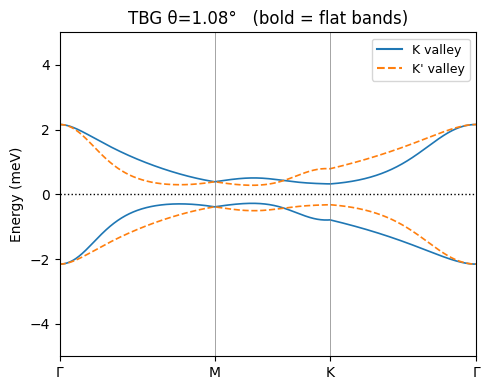

In [3]:
npath = 200
Gpt = np.array([0.0, 0.0])
Mpt = np.array([0.5, 0.0])
Kpt = np.array([1/3, 1/3])

kpath = np.vstack([
    np.linspace(Gpt, Mpt, npath, endpoint=False),
    np.linspace(Mpt, Kpt, npath, endpoint=False),
    np.linspace(Kpt, Gpt, npath, endpoint=True),
])

e_path = np.zeros((2, len(kpath), nb))
for t, tau in enumerate([-1, +1]):
    for ki, k in enumerate(kpath):
        e_path[t, ki] = np.linalg.eigvalsh(model.hamiltonian(k, valley=tau))

x = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(kpath, axis=0), axis=1))])
xticks = [x[0], x[npath], x[2*npath], x[-1]]

fig, ax = plt.subplots(figsize=(5, 4))
for n in range(nb):
    kw = dict(lw=1.2 if magic_bands[0] <= n < magic_bands[1] else 0.5,
              alpha=1.0 if magic_bands[0] <= n < magic_bands[1] else 0.25)
    ax.plot(x, e_path[0, :, n] * 1000, color='C0', **kw)
    ax.plot(x, e_path[1, :, n] * 1000, color='C1', ls='--', **kw)
ax.axhline(model.mu * 1000, color='k', ls=':', lw=1)
ax.set_xticks(xticks, ['Γ', 'M', 'K', 'Γ'])
for xt in xticks[1:-1]:
    ax.axvline(xt, color='gray', lw=0.5)
ax.set_ylabel('Energy (meV)')
ax.set_ylim(-5, 5)
ax.set_xlim(x[0], x[-1])
ax.set_title(f'TBG θ={model.theta}°   (bold = flat bands)')
ax.legend(handles=[
    plt.Line2D([], [], color='C0', label='K valley'),
    plt.Line2D([], [], color='C1', ls='--', label="K' valley"),
], fontsize=9)
plt.tight_layout()
plt.show()

## 3. Consistency check: χ(q=0, G=G'=0) vs χ_ph

At q = 0 the G = 0 form factor is the full orbital overlap, so
`chi_q[τ, τ', G₀, G₀]` must reproduce `chi_ph[τ, τ', τ', τ]`.

In [9]:
model.calculate_chi_ph_spinless()
chi_ph = model.chi_ph.copy()

# Qcut_chi=0: only G=G'=0, shape (2,2,1,1)  — G=0 is always at index 0
chi_q0_G0 = model.calculate_chi_q([0.0, 0.0], Qcut_chi=0)
G0 = chi_q0_G0.shape[2] // 2          # = 24 for Qcut_chi=3, 0 for Qcut_chi=0


print(f"chi_q shape with Qcut_chi=0: {chi_q0_G0.shape}\n")
print("chi_ph  vs  chi_q(G=G'=0):")
for tau in range(2):
    for taup in range(2):
        ref = chi_ph[tau, taup, taup, tau]
        got = chi_q0_G0[tau, taup, G0, G0].real
        print(f"  τ={tau} τ'={taup}:  chi_ph={ref:.6e}   chi_q={got:.6e}   diff={abs(ref-got):.1e}")

chi_q shape with Qcut_chi=0: (2, 2, 1, 1)

chi_ph  vs  chi_q(G=G'=0):
  τ=0 τ'=0:  chi_ph=5.046374e+02   chi_q=5.046374e+02   diff=2.8e-13
  τ=0 τ'=1:  chi_ph=8.403771e+01   chi_q=8.403771e+01   diff=2.3e-13
  τ=1 τ'=0:  chi_ph=8.403771e+01   chi_q=8.403771e+01   diff=2.4e-13
  τ=1 τ'=1:  chi_ph=5.040524e+02   chi_q=5.040524e+02   diff=5.7e-14


## 4. The full χ(q=0) matrix — effect of Qcut_chi

`Qcut_chi` controls the number of G-vectors in the output.  A smaller cutoff
discards the short-wavelength (large-G) components and is much cheaper to compute.

In [ ]:
chi_full = model.calculate_chi_q([0.0, 0.0], Qcut_chi=None) # (2,2,49,49)
chi_q1   = model.calculate_chi_q([0.0, 0.0], Qcut_chi=1)     # (2,2, 9, 9)

print(f"Qcut_chi=Qcut={model.Qcut} → shape {chi_full.shape}")
print(f"Qcut_chi=1    → shape {chi_q1.shape}")

valley_labels = ['K', "K'"]
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
vmax = np.abs(chi_full).max()

for tau in range(2):
    for taup in range(2):
        ax = axes[tau, taup]
        im = ax.imshow(chi_full[tau, taup].real, origin='lower',
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
        ax.set_title(f"Re χ[{valley_labels[tau]},{valley_labels[taup]}]", fontsize=11)
        ax.set_xlabel("G' index")
        ax.set_ylabel("G index")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Static χ(q=0; G, G\')   Qcut_chi={model.Qcut}  [eV⁻¹]', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Magic bands vs all bands

At the magic angle the two flat bands per valley dominate the low-energy response.
We compare the full χ with the flat-band-only result at q = 0.

In [ ]:
chi_magic = model.calculate_chi_q([0.0, 0.0], Qcut_chi=None, bands=magic_bands)

G0 = chi_full.shape[2] // 2   # G=(0,0) index; always ng//2 regardless of Qcut_chi

print(f"Band range for magic bands: {magic_bands}  (nb={nb})\n")
print(f"{'':12s}  {'full':>12s}  {'magic only':>12s}  {'ratio':>8s}")
print("-" * 55)
for tau in range(2):
    for taup in range(2):
        v_full  = chi_full [tau, taup, G0, G0].real * 1000
        v_magic = chi_magic[tau, taup, G0, G0].real * 1000
        ratio   = v_magic / v_full if v_full != 0 else float('nan')
        label = f"τ={tau},τ'={taup}"
        print(f"{label:12s}  {v_full:12.4f}  {v_magic:12.4f}  {ratio:8.3f}")
print("Units: meV⁻¹")

In [ ]:
# Visual comparison: intra-valley K block, full vs magic bands
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
vmax = np.abs(chi_full[0, 0]).max()
kw = dict(origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')

im0 = axes[0].imshow(chi_full [0, 0].real, **kw)
im1 = axes[1].imshow(chi_magic[0, 0].real, **kw)
diff = chi_full[0, 0].real - chi_magic[0, 0].real
vd = np.abs(diff).max()
im2 = axes[2].imshow(diff, origin='lower', cmap='RdBu_r', vmin=-vd, vmax=vd, interpolation='nearest')

for ax, im, title in zip(axes, [im0, im1, im2],
                         ['All bands', 'Magic bands only', 'Difference']):
    ax.set_title(title)
    ax.set_xlabel("G' index")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
axes[0].set_ylabel("G index")

fig.suptitle('Re χ[K,K](q=0; G, G\')  [eV⁻¹]', fontsize=12)
plt.tight_layout()
plt.show()

## 6. q-dependent charge susceptibility χ_c(q)

Using `Qcut_chi=0` the kernel computes only the G=G'=0 element, returning a **(2,2,1,1)**
array.  This avoids forming the full NG×NG matrix and is much faster for BZ scans.

In [ ]:
nq = 40
qpath = np.vstack([
    np.linspace(Gpt, Mpt, nq, endpoint=False),
    np.linspace(Mpt, Kpt, nq, endpoint=False),
    np.linspace(Kpt, Gpt, nq, endpoint=True),
])
dq = np.linalg.norm(np.diff(qpath, axis=0), axis=1)
xq = np.concatenate([[0], np.cumsum(dq)])
xticks_q = [xq[0], xq[nq], xq[2*nq], xq[-1]]

chi_c_all   = np.zeros(len(qpath))
chi_c_magic = np.zeros(len(qpath))

for qi, q in enumerate(qpath):
    # Qcut_chi=0: shape (2,2,1,1), G=0 is always index 0
    c_all   = model.calculate_chi_q(q, Qcut_chi=0)
    c_magic = model.calculate_chi_q(q, Qcut_chi=0, bands=magic_bands)
    chi_c_all  [qi] = (c_all  [0,0,0,0] + c_all  [1,1,0,0]).real
    chi_c_magic[qi] = (c_magic[0,0,0,0] + c_magic[1,1,0,0]).real

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(xq, chi_c_all   * 1000, 'C0-',  lw=1.5, label='all bands')
ax.plot(xq, chi_c_magic * 1000, 'C1--', lw=1.5, label='magic bands')
ax.set_xticks(xticks_q, ['Γ', 'M', 'K', 'Γ'])
for xt in xticks_q[1:-1]:
    ax.axvline(xt, color='gray', lw=0.5)
ax.set_ylabel('χ_c(q, G=0)  [meV⁻¹]')
ax.set_title(f'Charge susceptibility — TBG θ={model.theta}°, T={T} K, n={occ}')
ax.set_xlim(xq[0], xq[-1])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Inter-valley vs intra-valley at G = 0

In [ ]:
intra = np.zeros(len(qpath))
inter = np.zeros(len(qpath), dtype=complex)

for qi, q in enumerate(qpath):
    chi = model.calculate_chi_q(q, Qcut_chi=0)
    intra[qi] = (chi[0,0,0,0] + chi[1,1,0,0]).real
    inter[qi] =  chi[0,1,0,0] + chi[1,0,0,0]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(xq, intra      * 1000, 'C0-',  lw=1.5, label="intra-valley (K+K')")
ax.plot(xq, inter.real * 1000, 'C1--', lw=1.5, label='inter-valley Re')
ax.plot(xq, inter.imag * 1000, 'C1:',  lw=1.0, label='inter-valley Im')
ax.set_xticks(xticks_q, ['Γ', 'M', 'K', 'Γ'])
for xt in xticks_q[1:-1]:
    ax.axvline(xt, color='gray', lw=0.5)
ax.set_ylabel("χ(q, G=G'=0)  [meV⁻¹]")
ax.set_title('Intra- vs inter-valley susceptibility')
ax.legend(fontsize=9)
ax.set_xlim(xq[0], xq[-1])
plt.tight_layout()
plt.show()

## 8. Temperature dependence at q = 0

In [ ]:
temps = [5, 10, 20, 50, 100]

chi_T_all   = []
chi_T_magic = []

for T_val in temps:
    calculate_mu(model, occ=occ, T=T_val)
    c_all   = model.calculate_chi_q([0.0, 0.0], Qcut_chi=0)
    c_magic = model.calculate_chi_q([0.0, 0.0], Qcut_chi=0, bands=magic_bands)
    chi_T_all  .append((c_all  [0,0,0,0] + c_all  [1,1,0,0]).real * 1000)
    chi_T_magic.append((c_magic[0,0,0,0] + c_magic[1,1,0,0]).real * 1000)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(temps, chi_T_all,   'C0-o', ms=5, label='all bands')
ax.plot(temps, chi_T_magic, 'C1-s', ms=5, label='magic bands')
ax.set_xlabel('T  [K]')
ax.set_ylabel('χ_c(q=0, G=0)  [meV⁻¹]')
ax.set_title('Temperature dependence at Γ')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

calculate_mu(model, occ=occ, T=10.0)   # restore

## 9. Doping dependence

In [ ]:
fillings = np.linspace(-1.5, 1.5, 25)
chi_n_all   = np.zeros(len(fillings))
chi_n_magic = np.zeros(len(fillings))

for i, n in enumerate(fillings):
    calculate_mu(model, occ=n, T=10.0)
    c_all   = model.calculate_chi_q([0.0, 0.0], Qcut_chi=0)
    c_magic = model.calculate_chi_q([0.0, 0.0], Qcut_chi=0, bands=magic_bands)
    chi_n_all  [i] = (c_all  [0,0,0,0] + c_all  [1,1,0,0]).real * 1000
    chi_n_magic[i] = (c_magic[0,0,0,0] + c_magic[1,1,0,0]).real * 1000

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(fillings, chi_n_all,   'C0-o', ms=4, label='all bands')
ax.plot(fillings, chi_n_magic, 'C1-s', ms=4, label='magic bands')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Filling n  [10¹² cm⁻²]')
ax.set_ylabel('χ_c(q=0, G=0)  [meV⁻¹]')
ax.set_title(f'Doping scan — TBG θ={model.theta}°, T=10 K')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

calculate_mu(model, occ=0.0, T=10.0)   # restore

## 10. Full 2D mBZ map — magic bands, G=0

Using `Qcut_chi=0` and `bands=magic_bands` is the fastest way to scan the whole BZ.

In [ ]:
chi_map_all   = np.zeros((N, N))
chi_map_magic = np.zeros((N, N))
qn = np.arange(N) / N

for iqy in range(N):
    for iqx in range(N):
        q = [qn[iqx], qn[iqy]]
        c_all   = model.calculate_chi_q(q, Qcut_chi=0)
        c_magic = model.calculate_chi_q(q, Qcut_chi=0, bands=magic_bands)
        chi_map_all  [iqy, iqx] = (c_all  [0,0,0,0] + c_all  [1,1,0,0]).real
        chi_map_magic[iqy, iqx] = (c_magic[0,0,0,0] + c_magic[1,1,0,0]).real

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ext = [0, 1, 0, 1]
vmax = max(chi_map_all.max(), chi_map_magic.max()) * 1000

for ax, data, title in zip(axes,
                            [chi_map_all, chi_map_magic],
                            ['All bands', 'Magic bands only']):
    im = ax.imshow(data * 1000, origin='lower', cmap='inferno',
                   extent=ext, vmin=0, vmax=vmax, aspect='equal')
    ax.set_title(title)
    ax.set_xlabel('q_x  [mBZ frac.]')
    ax.set_ylabel('q_y  [mBZ frac.]')
    plt.colorbar(im, ax=ax, label='χ_c(q, G=0)  [meV⁻¹]')

fig.suptitle(f'Static charge susceptibility — TBG θ={model.theta}°, T=10 K, n=0', fontsize=12)
plt.tight_layout()
plt.show()